# GPLFR quickstart

A small, notebook-first introduction to GPLFR. This notebook fits a small GPLFR model and compares held-out predictions against the latent signal.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from gplfr import GPLFR, create_synthetic_data

## Generate a small structured dataset

The synthetic generator produces a predictable signal plus spatially correlated
nuisance fields. We fit on the noisy observations and inspect held-out signal
recovery.

In [2]:
data = create_synthetic_data(N=100, Dx=2, H=16, W=16, D_sig=3, ell=1.0, sigma_sig=1.0, sigma_nuis=0.3, sigma_eps=0.01, seed=0)
split = 80

X_train, Y_train = data["X"][:split], data["Y"][:split]
X_test, Y_sig_test = data["X"][split:], data["Y_sig"][split:]
H, W = int(data["H"]), int(data["W"])

X_t = torch.from_numpy(X_train)
Y_t = torch.from_numpy(Y_train)
print(f"train X: {tuple(X_t.shape)}  train Y: {tuple(Y_t.shape)}  test: {len(X_test)}")

train X: (80, 2)  train Y: (80, 256)  test: 20


## Fit GPLFR

This keeps the settings intentionally small and notebook-friendly. We only pass
a few real overrides beyond the defaults.

In [3]:
model = GPLFR(
    latent_dim=3,
    kernel="rbf",
    lengthscale_grouping="per_latent",
    amplitude_grouping="fixed",
    amplitude=1.0,
    inverse_temperature=0.1,
    device="auto",
)

fit_result = model.fit(
    X_t,
    Y_t,
    num_steps=500,
    verbose=False,
    seed=0,
)

print(f"final ELBO loss: {fit_result.final_loss:.4f}")

final ELBO loss: 184.0200


## Predict and inspect


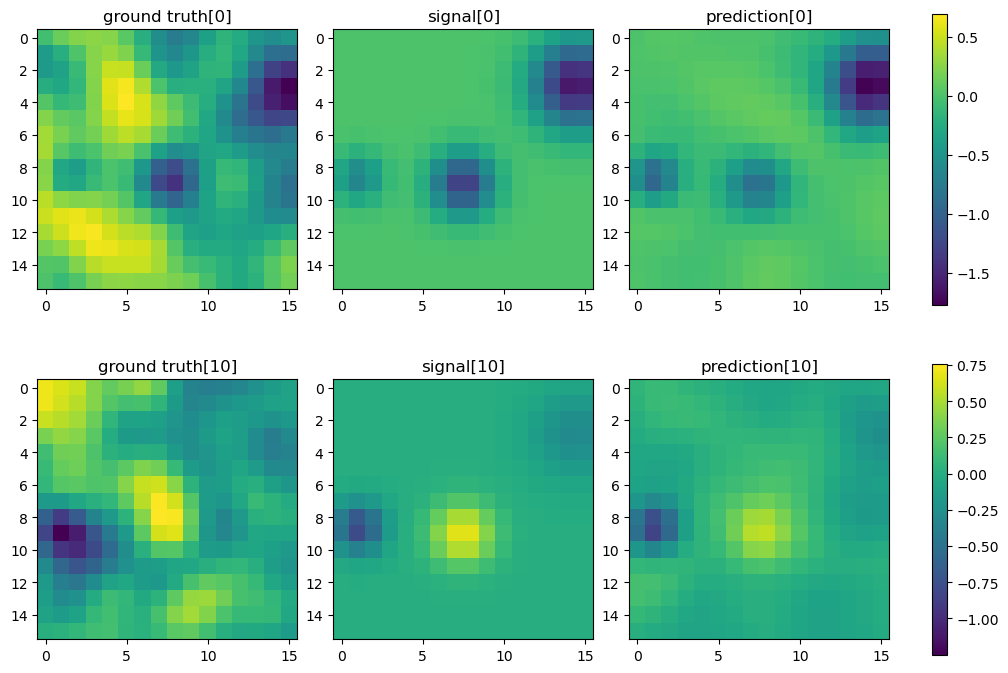

In [4]:
Y_pred = model.predict(torch.from_numpy(X_test)).reshape(-1, H, W)
Y_true = data["Y"][split:].reshape(-1, H, W)
Y_sig = Y_sig_test.reshape(-1, H, W)
rmse_sig = np.sqrt(np.mean((Y_pred - Y_sig) ** 2))
rmse_zero = np.sqrt(np.mean(Y_sig ** 2))
corr = np.corrcoef(Y_pred.ravel(), Y_sig.ravel())[0, 1]

fig, axes = plt.subplots(2, 3, figsize=(10, 7), constrained_layout=True)
for row, idx in enumerate((0, 10)):
    panels = ((Y_true[idx], f"ground truth[{idx}]"), (Y_sig[idx], f"signal[{idx}]"), (Y_pred[idx], f"prediction[{idx}]"))
    vmin = min(float(image.min()) for image, _ in panels)
    vmax = max(float(image.max()) for image, _ in panels)
    im = None
    for col, (image, title) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(image, cmap="viridis", vmin=vmin, vmax=vmax)
        ax.set_title(title)
    fig.colorbar(im, ax=axes[row, :], shrink=0.85)
plt.show()

## Predictive uncertainty

GPLFR predictions are distributional, not just point estimates.
`predict(..., return_std=True)` returns the marginal per-pixel
predictive standard deviation, and
`sample(X_new, n_samples)` draws samples from the predictive distribution. 

sample draws: (4, 20, 256) (n_samples, n_test, H*W)
signal within +/-2 std: 94.53%


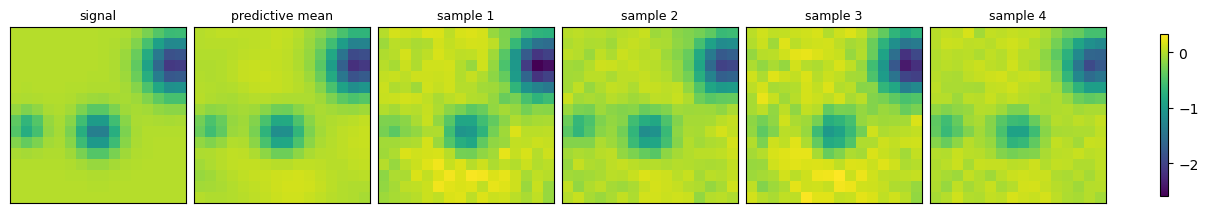

In [5]:
X_test_t = torch.from_numpy(X_test)
mean, std = model.predict(X_test_t, return_std=True)
draws = model.sample(X_test_t, n_samples=4, seed=0)
print(f"sample draws: {draws.shape} (n_samples, n_test, H*W)")

# Marginal calibration: how often the signal falls within +/- 2 std of the mean.
within_2std = np.mean(np.abs(Y_sig_test - mean) <= 2.0 * std)
print(f"signal within +/-2 std: {within_2std:.2%}")

# Predictive samples vary in a structured, spatially correlated way around the mean.
idx = -1
panels = [(Y_sig_test[idx].reshape(H, W), "signal"), (mean[idx].reshape(H, W), "predictive mean")]
panels += [(draws[s, idx].reshape(H, W), f"sample {s + 1}") for s in range(draws.shape[0])]
vmin = min(float(field.min()) for field, _ in panels)
vmax = max(float(field.max()) for field, _ in panels)
fig, axes = plt.subplots(1, len(panels), figsize=(2.0 * len(panels), 2.4), constrained_layout=True)
for ax, (field, title) in zip(axes, panels):
    im = ax.imshow(field, cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im, ax=axes, shrink=0.7)
plt.show()